In [2]:
import pandas as pd
import numpy as np

data_pad = "/Users/hbraakmann/Desktop/Jupyter/etmgeg_260.txt"
df = pd.read_csv(data_pad, sep=",", skiprows=50, skipinitialspace=True, usecols=["YYYYMMDD", "TG"])
df["YYYYMMDD"] = pd.to_datetime(df["YYYYMMDD"], format="%Y%m%d")
bilt = df.groupby([df["YYYYMMDD"].dt.year.rename("jaar"), df["YYYYMMDD"].dt.month.rename("maand")])["TG"].mean().reset_index()

maanden = {
    1:"januari", 2:"februari", 3:"maart", 4:"april", 5:"mei", 6:"juni",
    7:"juli", 8:"augustus", 9:"september", 10:"oktober", 11: "november", 12:"december"
}

bilt["maand"] = bilt["maand"].map(maanden)

bins = list(range(1900, 1991, 10))
labels = [f"{b}-{b+30}" for b in bins]

bilt["period"] = pd.cut(bilt["jaar"], bins=[*bins, bins[-1]+30], labels=labels, right=False)

bilt_dec = (bilt.groupby([bilt["period"], bilt["maand"]], observed=False)["TG"].mean()/10).round(2).reset_index()
bilt_dec

bilt_pivot = pd.pivot_table(bilt_dec, index="maand", columns="period", values="TG", observed=False).reindex(maanden.values())
bilt_pivot

period,1900-1930,1910-1940,1920-1950,1930-1960,1940-1970,1950-1980,1960-1990,1970-2000,1980-2010,1990-2020
maand,,,,,,,,,,
januari,1.63,2.28,2.75,3.27,0.11,1.88,1.63,2.45,2.05,3.60
februari,2.08,2.99,2.72,2.92,1.46,1.69,2.55,2.71,1.98,3.92
maart,4.55,5.03,5.24,4.94,4.83,5.12,4.67,4.89,5.17,6.54
april,7.66,7.75,7.78,8.06,9.40,7.92,8.60,7.33,8.13,9.78
mei,11.78,12.80,12.05,12.09,12.34,12.17,12.05,12.21,12.53,13.46
juni,14.51,14.55,13.95,15.54,14.95,15.11,15.27,15.32,15.06,16.07
juli,16.08,15.89,16.76,16.53,16.83,16.82,16.17,16.81,17.26,18.24
augustus,15.48,15.87,15.47,16.68,16.48,16.38,16.05,16.85,16.87,17.79
september,13.22,13.21,13.39,13.95,14.24,14.02,14.11,13.71,14.36,14.63


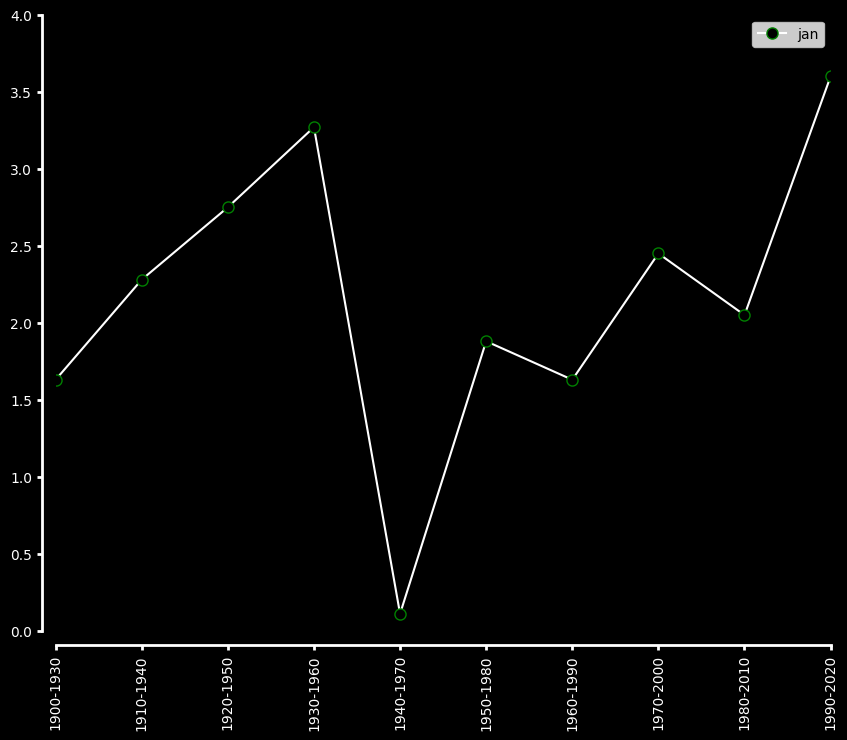

In [3]:
import matplotlib.pyplot as plt

plt.style.use("default")
#plt.rcParams["lines.linewidth"] = 4
#plt.rcParams["lines.linestyle"] = "--"
#plt.rcParams['figure.facecolor'] = 'yellow'
##plt.rcParams['axes.facecolor'] = 'lightblue'# Set axes background color to light blue
#plt.rcParams['font.size'] = 14              # Set font size to 14
#plt.rcParams['text.color'] = 'red' 


fig, ax = plt.subplots(figsize=(10,8))

ax.plot(bilt_pivot.columns, bilt_pivot.iloc[0], label="jan", marker="o",markersize=8, mfc="black", mec="green",color="white")
#ax.plot(bilt_pivot.columns, bilt_pivot.iloc[1], label="feb")
#ax.plot(bilt_pivot.columns, bilt_pivot.iloc[11], label="dec")

ax.spines[["left", "bottom"]].set_position(("outward", 10))
ax.set_facecolor("black")
ax.spines[["left", "bottom"]].set_linewidth(2)
ax.spines[["left", "bottom"]].set_color("white")
ax.tick_params(axis="both", width=2, color="white", labelcolor="white")

fig.set_facecolor("black")

ax.set_xticks(bilt_pivot.columns)
ax.set_xticklabels(bilt_pivot.columns, rotation=90)
ax.set_xlim(bilt_pivot.columns.min(), bilt_pivot.columns.max())
ax.set_yticks(np.arange(0, 5, 0.5))
ax.set_ylim(0, 4)
ax.legend()


plt.show()